In [60]:
import pandas as pd
from torch.nn import functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset
import torch
df = pd.read_csv('airfoil_data.csv')
df = df.iloc[:,1:] # remove the name of airofil as it is not useful to train NN.
df = df.dropna().copy()
df.iloc[:,3] = np.log(df.iloc[:,3])
df_target = df.iloc[:,2:5]
df_x = pd.concat([df.iloc[:,0:2], df.iloc[:,7:-5]], axis=1)
df

,reynoldsNumber,alpha,coefficientLift,coefficientDrag,coefficientMoment,topXTR,botXTR,max_thickness,thickness_position,max_camber,...,upper_slope_x_0.5_y,upper_slope_x_0.8_y,lower_slope_x_0.2_y,lower_slope_x_0.5_y,lower_slope_x_0.8_y,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
593,500000,-7.00,-0.2951,-4.302846,-0.0975,0.9947,0.0291,0.073389,0.296482,0.050354,...,0.031707,0.044332,0.049288,0.035140,0.103900,-0.068100,-0.159900,0.060600,0.020000,-0.055550
594,50000,0.25,0.2635,-3.805413,-0.0809,1.0000,1.0000,0.073389,0.296482,0.050354,...,0.031707,0.044332,0.049288,0.035140,0.103900,-0.068100,-0.159900,0.060600,0.020000,-0.055550
595,100000,-7.00,-0.3995,-2.420243,-0.0255,1.0000,0.0992,0.073389,0.296482,0.050354,...,0.031707,0.044332,0.049288,0.035140,0.103900,-0.068100,-0.159900,0.060600,0.020000,-0.055550
596,500000,2.00,0.7151,-5.043675,-0.1177,0.7185,1.0000,0.073389,0.296482,0.050354,...,0.031707,0.044332,0.049288,0.035140,0.103900,-0.068100,-0.159900,0.060600,0.020000,-0.055550
597,1000000,6.50,1.1705,-4.326781,-0.1101,0.0179,1.0000,0.073389,0.296482,0.050354,...,0.031707,0.044332,0.049288,0.035140,0.103900,-0.068100,-0.159900,0.060600,0.020000,-0.055550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,1000000,5.00,0.8155,-4.422849,-0.0808,0.0066,1.0000,0.090896,0.351759,0.030268,...,0.046369,0.016287,0.029130,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3464,200000,-3.75,-0.2325,-4.020722,-0.0715,0.9458,0.2461,0.090896,0.351759,0.030268,...,0.046369,0.016287,0.029130,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3465,100000,-3.75,-0.3898,-3.846235,-0.0421,1.0000,0.0860,0.090896,0.351759,0.030268,...,0.046369,0.016287,0.029130,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3466,200000,4.50,0.7836,-4.388447,-0.0837,0.3592,1.0000,0.090896,0.351759,0.030268,...,0.046369,0.016287,0.029130,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623


In [61]:
print(df_x.dtypes)
print(df_x.shape)

reynoldsNumber                 int64
alpha                        float64
max_thickness                float64
thickness_position           float64
max_camber                   float64
camber_position              float64
leading_edge_radius          float64
trailing_edge_angle_deg_y    float64
thickness_x_0.2_y            float64
thickness_x_0.4_y            float64
thickness_x_0.6_y            float64
thickness_x_0.8_y            float64
camber_x_0.25_y              float64
camber_x_0.5_y               float64
camber_x_0.75_y              float64
upper_slope_x_0.2_y          float64
upper_slope_x_0.5_y          float64
upper_slope_x_0.8_y          float64
lower_slope_x_0.2_y          float64
lower_slope_x_0.5_y          float64
lower_slope_x_0.8_y          float64
dtype: object
(2765, 21)


In [62]:
print(df.isna().sum())

reynoldsNumber               0
alpha                        0
coefficientLift              0
coefficientDrag              0
coefficientMoment            0
topXTR                       0
botXTR                       0
max_thickness                0
thickness_position           0
max_camber                   0
camber_position              0
leading_edge_radius          0
trailing_edge_angle_deg_y    0
thickness_x_0.2_y            0
thickness_x_0.4_y            0
thickness_x_0.6_y            0
thickness_x_0.8_y            0
camber_x_0.25_y              0
camber_x_0.5_y               0
camber_x_0.75_y              0
upper_slope_x_0.2_y          0
upper_slope_x_0.5_y          0
upper_slope_x_0.8_y          0
lower_slope_x_0.2_y          0
lower_slope_x_0.5_y          0
lower_slope_x_0.8_y          0
Unnamed: 27                  0
Unnamed: 28                  0
Unnamed: 29                  0
Unnamed: 30                  0
Unnamed: 31                  0
dtype: int64


In [64]:
df_target

,coefficientLift,coefficientDrag,coefficientMoment
593,-0.2951,-4.302846,-0.0975
594,0.2635,-3.805413,-0.0809
595,-0.3995,-2.420243,-0.0255
596,0.7151,-5.043675,-0.1177
597,1.1705,-4.326781,-0.1101
...,...,...,...
3463,0.8155,-4.422849,-0.0808
3464,-0.2325,-4.020722,-0.0715
3465,-0.3898,-3.846235,-0.0421
3466,0.7836,-4.388447,-0.0837


In [65]:
from sklearn.model_selection import train_test_split

features = torch.tensor(df_x.values, dtype=torch.float32)
labels = torch.tensor(df_target.values, dtype=torch.float32)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

X_mean = torch.mean(X_train, dim=0, keepdim=True)
X_std = torch.std(X_train, dim=0, keepdim=True)

y_mean = torch.mean(y_train, dim=0, keepdim=True)
y_std = torch.std(y_train, dim=0, keepdim=True)

x_train = (X_train - X_mean) / X_std
y_train = (y_train - y_mean) / y_std
x_test = (X_test - X_mean) / X_std
y_test = (y_test - y_mean) / y_std

Using device: cuda
Model params: 111,875
Train: 2212 | Test: 553
Epoch    1 | Train MSE 0.458924 | Test MSE 0.190472 | LR 1.00e-03
Epoch  100 | Train MSE 0.044585 | Test MSE 0.067420 | LR 9.33e-04
Epoch  200 | Train MSE 0.024881 | Test MSE 0.063866 | LR 7.50e-04
Epoch  300 | Train MSE 0.017720 | Test MSE 0.063140 | LR 5.01e-04
Epoch  400 | Train MSE 0.010268 | Test MSE 0.063996 | LR 2.51e-04
Epoch  500 | Train MSE 0.009768 | Test MSE 0.062700 | LR 6.79e-05
Epoch  600 | Train MSE 0.009047 | Test MSE 0.063019 | LR 1.00e-06

── R² scores (test set) ──
  CL: 0.9815
  CD: 0.9312
  CM: 0.8934


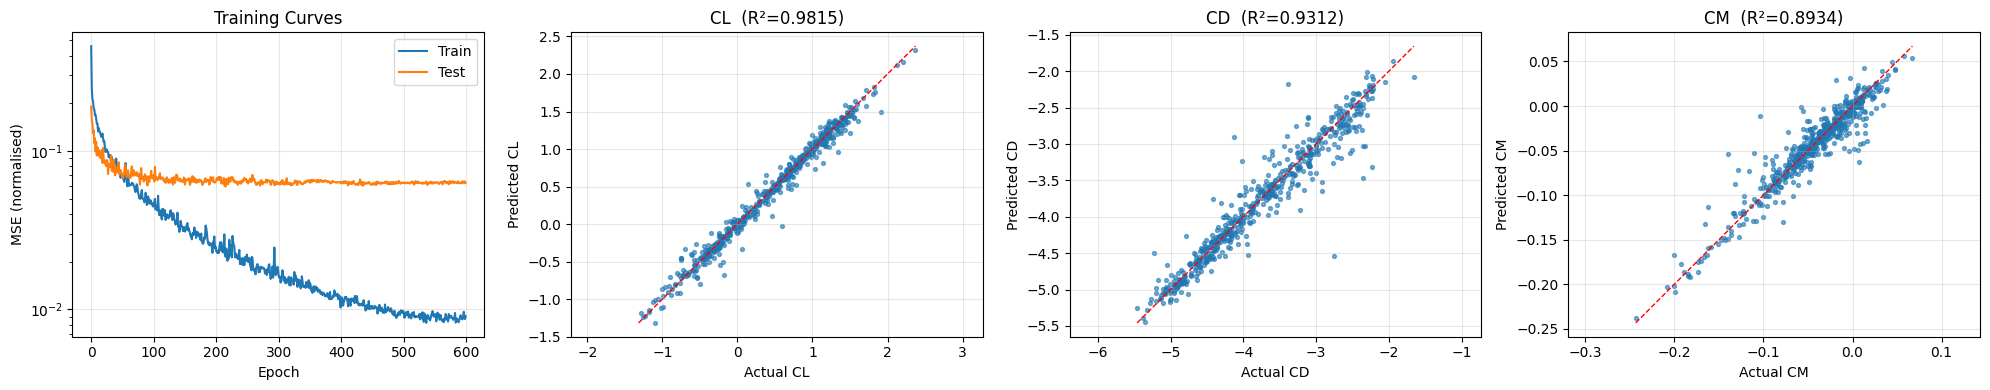

In [69]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ── Model ────────────────────────────────────────────────────────────────────
class AirfoilNet(nn.Module):
    """MLP with residual skip, BatchNorm, and dropout."""
    def __init__(self, in_dim, out_dim, hidden=128):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU())

        # Two residual blocks
        self.block1 = self._res_block(hidden)
        self.block2 = self._res_block(hidden)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, out_dim),
        )

    @staticmethod
    def _res_block(dim, drop=0.1):
        return nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
        )

    def forward(self, x):
        h = self.stem(x)
        h = h + self.block1(h)          # skip connection
        h = h + self.block2(h)          # skip connection
        return self.head(h)

# ── Setup ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

in_dim  = x_train.shape[1]     # 6 features (after fixing the leak)
out_dim = y_train.shape[1]     # 3 targets: CL, CD, CM

model     = AirfoilNet(in_dim, out_dim, hidden=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600, eta_min=1e-6)

train_loader = DataLoader(
    TensorDataset(x_train.to(device), y_train.to(device)),
    batch_size=32, shuffle=True
)
x_te = x_test.to(device)
y_te = y_test.to(device)

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Train: {len(x_train)} | Test: {len(x_test)}")

# ── Training loop ────────────────────────────────────────────────────────────
EPOCHS = 600
train_hist, test_hist = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    train_mse = epoch_loss / len(x_train)
    train_hist.append(train_mse)

    model.eval()
    with torch.no_grad():
        test_mse = criterion(model(x_te), y_te).item()
    test_hist.append(test_mse)
    scheduler.step()

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Train MSE {train_mse:.6f} | Test MSE {test_mse:.6f} | LR {scheduler.get_last_lr()[0]:.2e}")

# ── Evaluation ───────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_norm = model(x_te)

    # un-normalise to physical units
    preds   = preds_norm * y_std.to(device) + y_mean.to(device)
    actuals = y_te       * y_std.to(device) + y_mean.to(device)

    ss_res = ((actuals - preds) ** 2).sum(dim=0)
    ss_tot = ((actuals - actuals.mean(dim=0)) ** 2).sum(dim=0)
    r2 = (1 - ss_res / ss_tot).cpu().numpy()

names = ['CL', 'CD', 'CM']
print("\n── R² scores (test set) ──")
for n, s in zip(names, r2):
    print(f"  {n}: {s:.4f}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Loss curves
axes[0].semilogy(train_hist, label='Train')
axes[0].semilogy(test_hist,  label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (normalised)')
axes[0].set_title('Training Curves'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parity plots (predicted vs actual, physical units)
p_cpu = preds.cpu().numpy()
a_cpu = actuals.cpu().numpy()
for i, name in enumerate(names):
    ax = axes[i + 1]
    ax.scatter(a_cpu[:, i], p_cpu[:, i], s=8, alpha=0.6)
    lims = [min(a_cpu[:, i].min(), p_cpu[:, i].min()),
            max(a_cpu[:, i].max(), p_cpu[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'Actual {name}'); ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  (R²={r2[i]:.4f})')
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


In [70]:
# Save model + normalisation params
import torch, os

torch.save({
    "model_state_dict": model.state_dict(),
    "in_dim": 21,
    "out_dim": 3,
    "X_mean": X_mean.cpu(),
    "X_std":  X_std.cpu(),
    "y_mean": y_mean.cpu(),
    "y_std":  y_std.cpu(),
}, "airfoil_surrogate.pt")


print("Saved.")


Saved.


In [71]:
"""
nn_surrogate.py
───────────────
Wraps the trained AirfoilNet into two callables:

  • surrogate_fn(x_phys)  → returns  -CL/CD   (scalar)
  • surrogate_grad(x_phys) → returns  d(-CL/CD)/dx   (same shape as x_phys)

x_phys is a 1-D numpy array (or list) of the design variables in PHYSICAL
units.  The exact ordering must match the columns of ``df_x`` built in
main.ipynb (reynoldsNumber, alpha, + 19 geometry features → 21 total).

The network was trained with the *log* of CD (``np.log(cd)``),
so the second output column is log(CD).  When computing CL/CD,
this module first converts log(CD) → CD  via ``torch.exp()``.

These two functions are all you need to hand to any gradient-based
*or* derivative-free optimiser (scipy.optimize.minimize, COBYQA, etc.).

Usage (after running main.ipynb cells 0–4 so that model, X_mean, X_std,
y_mean, y_std, and device are all in scope):

    from nn_surrogate import build_surrogate
    surrogate_fn, surrogate_grad, surrogate_fn_and_grad = build_surrogate(
        model, X_mean, X_std, y_mean, y_std, device
    )

    # Now use them however you like:
    val  = surrogate_fn(x0)       # scalar  −CL/CD
    grad = surrogate_grad(x0)     # np array of shape (n_features,)
"""

import numpy as np
import torch


def build_surrogate(model, X_mean, X_std, y_mean, y_std, device):
    """
    Returns (surrogate_fn, surrogate_grad, surrogate_fn_and_grad).

    Both accept a 1-D numpy array of physical design variables and
    return numpy scalars / arrays, so they slot straight into
    scipy.optimize or any other framework.
    """

    # ── freeze the network weights ──────────────────────────────────────
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    n_features = X_mean.shape[-1]


    xm = X_mean.to(device).squeeze()  
    xs = X_std.to(device).squeeze()
    ym = y_mean.to(device).squeeze()  
    ys = y_std.to(device).squeeze()

    def _to_normalised_tensor(x_phys):
        """Convert a 1-D numpy/list input to a normalised, grad-enabled tensor."""
        x_t = torch.tensor(np.asarray(x_phys, dtype=np.float32),
                           dtype=torch.float32, device=device)
        x_t = x_t.detach().requires_grad_(True)           # design variables need grad
        x_norm = (x_t - xm) / xs                          # z-score normalise
        return x_t, x_norm.unsqueeze(0)                    # add batch dim → (1, n_features)

    # ── helper: run model, denormalise, compute −CL/CD ──────────────────
    def _forward(x_phys):

        x_t, x_norm = _to_normalised_tensor(x_phys)
        y_norm = model(x_norm)                             # (1, 3) normalised
        y_phys = y_norm * ys + ym                          # de-normalise → (1, 3)

        cl     = y_phys[0, 0]
        log_cd = y_phys[0, 1]                              # the model predicts log(CD)
        cd     = torch.exp(log_cd)                         # convert to actual CD
        # small eps to avoid division by zero if CD ≈ 0
        obj = -(cl / (cd + 1e-8))
        return x_t, obj

    # ── public API ──────────────────────────────────────────────────────
    def surrogate_fn(x_phys):
        """Evaluate −CL/CD at a physical design point.  Returns a float."""
        with torch.enable_grad():
            _, obj = _forward(x_phys)
        return float(obj.detach().cpu())

    def surrogate_grad(x_phys):
        """Gradient of −CL/CD w.r.t. the physical design variables.
        Returns a numpy array of shape (n_features,)."""
        with torch.enable_grad():
            x_t, obj = _forward(x_phys)
            obj.backward()
        return x_t.grad.detach().cpu().numpy()

    def surrogate_fn_and_grad(x_phys):
        """
        Convenience function that returns BOTH value and gradient in one
        forward+backward pass (more efficient than calling the two above
        separately).  Useful for scipy L-BFGS-B which wants jac=True.

        Returns
        -------
        val  : float
        grad : np.ndarray of shape (n_features,)
        """
        with torch.enable_grad():
            x_t, obj = _forward(x_phys)
            obj.backward()
        return float(obj.detach().cpu()), x_t.grad.detach().cpu().numpy()

    return surrogate_fn, surrogate_grad, surrogate_fn_and_grad



In [72]:
# Load model (skip retraining)
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("airfoil_surrogate.pt", map_location=device, weights_only=True)

# Rebuild the model architecture (same as training cell) then load weights
model = AirfoilNet(in_dim=ckpt["in_dim"], out_dim=ckpt["out_dim"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

X_mean = ckpt["X_mean"].to(device)
X_std  = ckpt["X_std"].to(device)
y_mean = ckpt["y_mean"].to(device)
y_std  = ckpt["y_std"].to(device)

print("Loaded.")

Loaded.


In [73]:
f, f_grad, _ =build_surrogate(model, X_mean, X_std, y_mean, y_std, device)

In [108]:
x_phys = df_x.iloc[-2,:]
x_phys

reynoldsNumber               200000.000000
alpha                             4.500000
max_thickness                     0.090896
thickness_position                0.351759
max_camber                        0.030268
camber_position                   0.592965
leading_edge_radius               0.003158
trailing_edge_angle_deg_y         0.090896
thickness_x_0.2_y                 0.351759
thickness_x_0.4_y                 0.030268
thickness_x_0.6_y                 0.592965
thickness_x_0.8_y                 0.003158
camber_x_0.25_y                  13.826467
camber_x_0.5_y                    0.084954
camber_x_0.75_y                   0.090341
upper_slope_x_0.2_y               0.078789
upper_slope_x_0.5_y               0.046369
upper_slope_x_0.8_y               0.016287
lower_slope_x_0.2_y               0.029130
lower_slope_x_0.5_y               0.025087
lower_slope_x_0.8_y               0.127835
Name: 3466, dtype: float64

In [109]:
neg_cl_cd = f(x_phys)

In [110]:
log_cd = df_target.iloc[-2,1]
cd = np.exp(log_cd)
cl = df_target.iloc[-2,0]
actual_cl_cd = -cl/cd

In [111]:
print(f"model accuracy to predict Cl over Cd is: {100 - np.abs(np.abs(actual_cl_cd) - np.abs(neg_cl_cd))/np.abs(actual_cl_cd)*100}%",)


model accuracy to predict Cl over Cd is: 98.11974144274025%
